In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import neuron
importlib.reload(neuron)
from neuron import Neuron
neuron = Neuron()

def initialize_weights_and_bias():
    initial_W = list(np.random.uniform(-1, 1, 9))
    initial_bias = np.random.uniform(-1, 1)
    return initial_W, initial_bias
 
train = pd.read_csv('train.csv')
validation = pd.read_csv('validation.csv') 
test = pd.read_csv('test.csv')
    

In [53]:
initial_W, initial_bias = initialize_weights_and_bias()

sgd_w, sgd_bias, sgd_train_errors, sgd_train_accuracies, sgd_validation_errors, sgd_validation_accuracies, sgd_test_error, sgd_test_accuracy, sgd_test_calc_df, sgd_training_time, sgd_best_epoch = neuron.stochastic_gradient_descent(
    train.copy(), validation.copy(), test.copy(), initial_W.copy(), initial_bias, learning_rate=0.03, epochs=1000, emin=0.01)

bgd_w, bgd_bias, bgd_train_errors, bgd_train_accuracies, bgd_validation_errors, bgd_validation_accuracies, bgd_test_error, bgd_test_accuracy, bgd_test_calc_df, bgd_training_time, bgd_best_epoch = neuron.batch_gradient_descent(
    train.copy(), validation.copy(), test.copy(), initial_W.copy(), initial_bias, learning_rate=0.03, epochs=1000, emin=0.01)

In [54]:
sgd_03_row = sgd_best_epoch.copy()
sgd_03_row["test_error"] = sgd_test_error
sgd_03_row["test_accuracy"] = sgd_test_accuracy
sgd_03_row["training_time"] = sgd_training_time
sgd_03_row["test_calc_df"] = sgd_test_calc_df
sgd_03_row["last_train_error"] = sgd_train_errors[-1]
sgd_03_row["last_train_accuracy"] = sgd_train_accuracies[-1]
sgd_03_row["last_validation_error"] = sgd_validation_errors[-1]
sgd_03_row["last_validation_accuracy"] = sgd_validation_accuracies[-1]
sgd_03_row["last_weights"] = sgd_w
sgd_03_row["last_bias"] = sgd_bias

bgd_03_row = bgd_best_epoch.copy()
bgd_03_row["test_error"] = bgd_test_error
bgd_03_row["test_accuracy"] = bgd_test_accuracy
bgd_03_row["training_time"] = bgd_training_time
bgd_03_row["test_calc_df"] = bgd_test_calc_df
bgd_03_row["last_train_error"] = bgd_train_errors[-1]
bgd_03_row["last_train_accuracy"] = bgd_train_accuracies[-1]
bgd_03_row["last_validation_error"] = bgd_validation_errors[-1]
bgd_03_row["last_validation_accuracy"] = bgd_validation_accuracies[-1]
bgd_03_row["last_weights"] = bgd_w
bgd_03_row["last_bias"] = bgd_bias

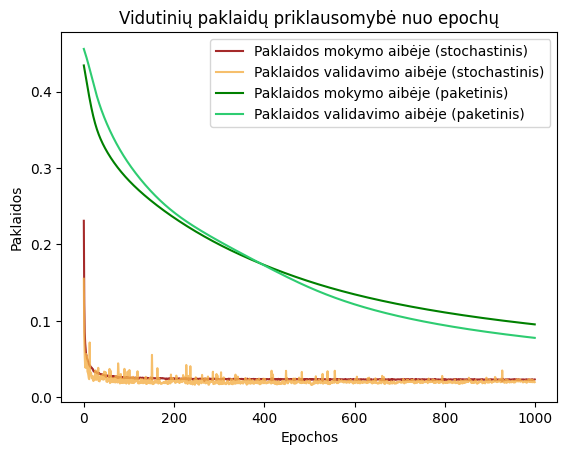

In [55]:
plt.plot(sgd_train_errors, label='Paklaidos mokymo aibėje (stochastinis)', color= 'brown')
plt.plot(sgd_validation_errors, label='Paklaidos validavimo aibėje (stochastinis)', color="#F5B24DD3")
plt.plot(bgd_train_errors, label='Paklaidos mokymo aibėje (paketinis)', color='green')
plt.plot(bgd_validation_errors, label='Paklaidos validavimo aibėje (paketinis)', color='#2ECC71')
plt.xlabel("Epochos")
plt.ylabel("Paklaidos")
plt.title("Vidutinių paklaidų priklausomybė nuo epochų")
plt.legend()
plt.show()

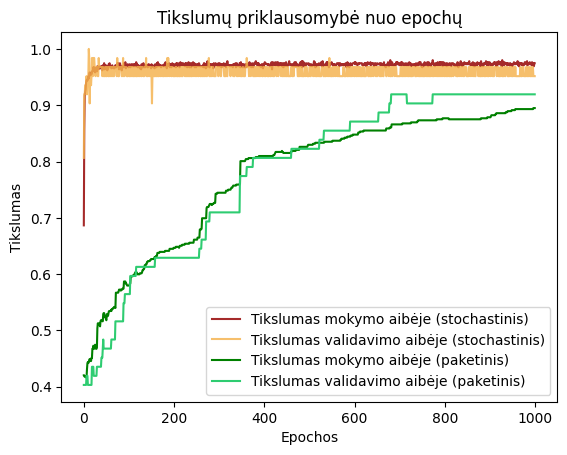

In [56]:
plt.plot(sgd_train_accuracies, label='Tikslumas mokymo aibėje (stochastinis)', color='brown')
plt.plot(sgd_validation_accuracies, label='Tikslumas validavimo aibėje (stochastinis)', color="#F5B24DD3")
plt.plot(bgd_train_accuracies, label='Tikslumas mokymo aibėje (paketinis)', color='green')
plt.plot(bgd_validation_accuracies, label='Tikslumas validavimo aibėje (paketinis)', color='#2ECC71')
plt.xlabel("Epochos")
plt.ylabel("Tikslumas")
plt.title("Tikslumų priklausomybė nuo epochų")
plt.legend()
plt.show()

In [57]:
print("Stochastinis:")
display(sgd_best_epoch)
print("test acc: ", sgd_test_accuracy, ", test error: ", sgd_test_error)
print("Paketinis:")
display(bgd_best_epoch)
print("test acc: ", bgd_test_accuracy, ", test error: ", bgd_test_error)

Stochastinis:


{'score': 0.974916172795563,
 'learning_rate': 0.03,
 'epoch_indx': 11,
 'train_error': 0.04407379463960372,
 'validation_error': 0.02508382720443705,
 'train_accuracy': 0.947463768115942,
 'validation_accuracy': 1.0,
 'weights': [np.float64(0.04652203349070708),
  np.float64(0.8038276817563956),
  np.float64(0.15956157893927123),
  np.float64(0.14704505435173443),
  np.float64(-0.3537122938806749),
  np.float64(0.49139918507318525),
  np.float64(-0.2507156385247943),
  np.float64(0.2496023862007932),
  np.float64(-0.09671793551450343)],
 'bias': -2.7913400953642884}

test acc:  0.9565217391304348 , test error:  0.04019245362235049
Paketinis:


{'score': 0.8414705014551488,
 'learning_rate': 0.03,
 'epoch_indx': 999,
 'train_error': 0.09552090231127702,
 'validation_error': 0.07788433725452862,
 'train_accuracy': 0.894927536231884,
 'validation_accuracy': 0.9193548387096774,
 'weights': [np.float64(-0.247861926309184),
  np.float64(0.4399677895777849),
  np.float64(-0.1741900244406098),
  np.float64(0.5260908609779535),
  np.float64(-0.22427095391639523),
  np.float64(0.7479903665972261),
  np.float64(-0.8494462008641439),
  np.float64(0.5107418792608124),
  np.float64(0.2497893768505754)],
 'bias': -1.4571815386354334}

test acc:  0.9420289855072463 , test error:  0.05282777404896397


In [58]:
print(initial_bias)
for i in range(len(initial_W)):
    print(f"W{i+1}: {round(initial_W[i], 4)}")


-0.6786066957255303
W1: 0.4626
W2: -0.1478
W3: -0.8286
W4: 0.8754
W5: 0.5203
W6: 0.4109
W7: -0.9469
W8: 0.5971
W9: 0.8678


In [59]:
print(list(initial_W))

[np.float64(0.46261929704887295), np.float64(-0.14783781601142443), np.float64(-0.8285561617802488), np.float64(0.8754157288222029), np.float64(0.5203132278789993), np.float64(0.41092936146215453), np.float64(-0.9469244709930309), np.float64(0.5971116251735777), np.float64(0.8677532815964675)]


In [60]:
print(sgd_training_time)
print(bgd_training_time)

45.886157512664795
45.18680238723755


In [61]:
learning_rates = [0.01, 0.1, 0.5, 0.9]
sgd_best_epochs = []
for i, lr in enumerate(learning_rates):
    sgd_w_temp, sgd_bias_temp, sgd_train_errors_temp, sgd_train_accuracies_temp, sgd_validation_errors_temp, sgd_validation_accuracies_temp, sgd_test_error_temp, sgd_test_accuracy_temp, sgd_test_calc_df_temp, sgd_training_time_temp, sgd_best_epoch_temp = neuron.stochastic_gradient_descent(
        train.copy(), validation.copy(), test.copy(), initial_W.copy(), initial_bias, learning_rate=lr, epochs=1000, emin=0.01)
    
    sgd_best_epoch_temp["test_error"] = sgd_test_error_temp
    sgd_best_epoch_temp["test_accuracy"] = sgd_test_accuracy_temp
    sgd_best_epoch_temp["training_time"] = sgd_training_time_temp
    sgd_best_epoch_temp["test_calc_df"] = sgd_test_calc_df_temp

    sgd_best_epoch_temp["last_train_error"] = sgd_train_errors_temp[-1]
    sgd_best_epoch_temp["last_train_accuracy"] = sgd_train_accuracies_temp[-1]
    sgd_best_epoch_temp["last_validation_error"] = sgd_validation_errors_temp[-1]
    sgd_best_epoch_temp["last_validation_accuracy"] = sgd_validation_accuracies_temp[-1]
    sgd_best_epoch_temp["last_weights"] = sgd_w_temp
    sgd_best_epoch_temp["last_bias"] = sgd_bias_temp

    sgd_best_epochs.append(sgd_best_epoch_temp)

best_sgd_parameters = pd.DataFrame(sgd_best_epochs)
best_sgd_parameters = pd.concat(
    [best_sgd_parameters, pd.DataFrame([sgd_03_row])], ignore_index=True
).sort_values('learning_rate').reset_index(drop=True)

display(best_sgd_parameters)


,score,learning_rate,epoch_indx,train_error,validation_error,train_accuracy,validation_accuracy,weights,bias,test_error,test_accuracy,training_time,test_calc_df,last_train_error,last_train_accuracy,last_validation_error,last_validation_accuracy,last_weights,last_bias
0,0.959380,0.01,61,0.033502,0.024491,0.963768,0.983871,"[0.11299565600441039, 0.5729942795132724, 0.14...",-3.420013,0.020882,0.985507,45.814970,Clump_thickness Uniformity_of_cell_size ...,0.023078,0.971014,0.021031,0.967742,"[0.3534228171955253, 0.2864176952415783, 0.326...",-7.351725
1,0.974916,0.03,11,0.044074,0.025084,0.947464,1.000000,"[0.04652203349070708, 0.8038276817563956, 0.15...",-2.791340,0.040192,0.956522,45.886158,Clump_thickness Uniformity_of_cell_size ...,0.023513,0.974638,0.020042,0.951613,"[0.4643087515423984, 0.36649966722819655, 0.51...",-9.442912
2,0.983044,0.10,6,0.048676,0.016956,0.934783,1.000000,"[0.057232407220745476, 0.8897006483073682, 0.2...",-3.746291,0.034823,0.971014,45.656657,Clump_thickness Uniformity_of_cell_size ...,0.023088,0.974638,0.032585,0.951613,"[0.5634252267289684, 0.5793101923702161, 1.135...",-15.651973
3,0.994649,0.50,441,0.031409,0.005351,0.961957,1.000000,"[0.9587741201889708, 1.3404827182067798, 1.070...",-18.716985,0.008712,0.985507,45.555891,Clump_thickness Uniformity_of_cell_size ...,0.021928,0.976449,0.039229,0.951613,"[1.4783811740502175, 1.4422697852157336, 3.119...",-39.997231
4,0.998593,0.90,31,0.061508,0.001407,0.931159,1.000000,"[-0.2788027110879082, 4.428306285474318, 1.633...",-22.011773,0.021881,0.971014,45.870028,Clump_thickness Uniformity_of_cell_size ...,0.019967,0.980072,0.032391,0.967742,"[2.1121493281960104, 3.105940941315494, 5.4875...",-68.417978


In [62]:
learning_rates = [0.01, 0.1, 0.5, 0.9]
bgd_best_epochs = []
for i, lr in enumerate(learning_rates):
    bgd_w_temp, bgd_bias_temp, bgd_train_errors_temp, bgd_train_accuracies_temp, bgd_validation_errors_temp, bgd_validation_accuracies_temp, bgd_test_error_temp, bgd_test_accuracy_temp, bgd_test_calc_df_temp, bgd_training_time_temp, bgd_best_epoch_temp = neuron.batch_gradient_descent(
        train.copy(), validation.copy(), test.copy(), initial_W.copy(), initial_bias, learning_rate=lr, epochs=1000, emin=0.01)
    
    bgd_best_epoch_temp["test_error"] = bgd_test_error_temp
    bgd_best_epoch_temp["test_accuracy"] = bgd_test_accuracy_temp
    bgd_best_epoch_temp["training_time"] = bgd_training_time_temp
    bgd_best_epoch_temp["test_calc_df"] = bgd_test_calc_df_temp

    bgd_best_epoch_temp["last_train_error"] = bgd_train_errors_temp[-1]
    bgd_best_epoch_temp["last_train_accuracy"] = bgd_train_accuracies_temp[-1]
    bgd_best_epoch_temp["last_validation_error"] = bgd_validation_errors_temp[-1]
    bgd_best_epoch_temp["last_validation_accuracy"] = bgd_validation_accuracies_temp[-1]
    bgd_best_epoch_temp["last_weights"] = bgd_w_temp
    bgd_best_epoch_temp["last_bias"] = bgd_bias_temp

    bgd_best_epochs.append(bgd_best_epoch_temp)

best_bgd_parameters = pd.DataFrame(bgd_best_epochs)
best_bgd_parameters = pd.concat(
    [best_bgd_parameters, pd.DataFrame([bgd_03_row])], ignore_index=True
).sort_values('learning_rate').reset_index(drop=True)

display(best_bgd_parameters)

,score,learning_rate,epoch_indx,train_error,validation_error,train_accuracy,validation_accuracy,weights,bias,test_error,test_accuracy,training_time,test_calc_df,last_train_error,last_train_accuracy,last_validation_error,last_validation_accuracy,last_weights,last_bias
0,0.516023,0.01,999,0.190322,0.193655,0.757246,0.709677,"[-0.07928697742499728, 0.04908360425508982, -0...",-1.047129,0.133208,0.869565,45.047601,Clump_thickness Uniformity_of_cell_size ...,0.190322,0.757246,0.193655,0.709677,"[-0.07928697742499728, 0.04908360425508982, -0...",-1.047129
1,0.841471,0.03,999,0.095521,0.077884,0.894928,0.919355,"[-0.247861926309184, 0.4399677895777849, -0.17...",-1.457182,0.052828,0.942029,45.186802,Clump_thickness Uniformity_of_cell_size ...,0.095521,0.894928,0.077884,0.919355,"[-0.247861926309184, 0.4399677895777849, -0.17...",-1.457182
2,0.909659,0.10,853,0.053008,0.041954,0.940217,0.951613,"[-0.11187493640359453, 0.7221695277052341, 0.1...",-2.037483,0.029560,0.985507,45.245606,Clump_thickness Uniformity_of_cell_size ...,0.050129,0.943841,0.041404,0.935484,"[-0.08954340196657745, 0.7357667246311416, 0.1...",-2.151578
3,0.921903,0.50,999,0.029973,0.029710,0.963768,0.951613,"[0.12373317046825011, 0.43796456372727627, 0.1...",-3.897550,0.010643,1.000000,44.987245,Clump_thickness Uniformity_of_cell_size ...,0.029973,0.963768,0.029710,0.951613,"[0.12373317046825011, 0.43796456372727627, 0.1...",-3.897550
4,0.942145,0.90,999,0.026325,0.025597,0.971014,0.967742,"[0.1870071879995048, 0.31663592664068024, 0.21...",-4.714523,0.006357,1.000000,44.909256,Clump_thickness Uniformity_of_cell_size ...,0.026325,0.971014,0.025597,0.967742,"[0.1870071879995048, 0.31663592664068024, 0.21...",-4.714523


In [67]:
best_idx = best_bgd_parameters['score'].idxmax()

display(best_bgd_parameters.iloc[best_idx]['test_calc_df'])


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,label,predicted_label
0,3.0,2.0,2.0,3.0,2.0,3,3.0,1.0,1.0,0.0,0
1,10.0,6.0,5.0,8.0,5.0,10,8.0,6.0,1.0,1.0,1
2,10.0,7.0,7.0,4.0,5.0,10,5.0,7.0,2.0,1.0,1
3,2.0,1.0,1.0,1.0,2.0,1,2.0,1.0,1.0,0.0,0
4,10.0,6.0,6.0,2.0,4.0,10,9.0,7.0,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
64,1.0,1.0,1.0,1.0,2.0,1,2.0,1.0,1.0,0.0,0
65,1.0,1.0,1.0,1.0,2.0,1,1.0,1.0,1.0,0.0,0
66,1.0,1.0,1.0,3.0,2.0,1,1.0,1.0,1.0,0.0,0
67,1.0,1.0,1.0,1.0,2.0,1,3.0,1.0,1.0,0.0,0


In [68]:
best_results = best_sgd_parameters.iloc[best_idx]['test_calc_df']
best_results.to_csv('best_sgd_test_results.csv', index=False)
best_results

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,label,predicted_label
0,3.0,2.0,2.0,3.0,2.0,3,3.0,1.0,1.0,0.0,0
1,10.0,6.0,5.0,8.0,5.0,10,8.0,6.0,1.0,1.0,1
2,10.0,7.0,7.0,4.0,5.0,10,5.0,7.0,2.0,1.0,1
3,2.0,1.0,1.0,1.0,2.0,1,2.0,1.0,1.0,0.0,0
4,10.0,6.0,6.0,2.0,4.0,10,9.0,7.0,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
64,1.0,1.0,1.0,1.0,2.0,1,2.0,1.0,1.0,0.0,0
65,1.0,1.0,1.0,1.0,2.0,1,1.0,1.0,1.0,0.0,0
66,1.0,1.0,1.0,3.0,2.0,1,1.0,1.0,1.0,0.0,0
67,1.0,1.0,1.0,1.0,2.0,1,3.0,1.0,1.0,0.0,0


In [64]:
print("Stochastinis:", sgd_test_accuracy, sgd_test_error)
print("Paketinis:", bgd_test_accuracy, bgd_test_error)

Stochastinis: 0.9565217391304348 0.04019245362235049
Paketinis: 0.9420289855072463 0.05282777404896397
